# 3 — Baseline Models for Movie Success Prediction

This notebook trains and evaluates three baseline classifiers — **Logistic Regression**, **Random Forest**, and **XGBoost** — on two binary prediction tasks:

1. **Commercial success** (`is_commercial`): whether a film's ROI ≥ 2.0
2. **Award nomination** (`is_award_winner`): whether a film received an Oscar nomination

All heavy lifting (splitting, scaling, SMOTE, training, plotting) is delegated to reusable helpers in `src/models.py` and `src/data_loader.py`.
The notebook itself stays **narrative-focused**: each section explains *what* we do and *why*, then shows a short code cell, followed by a brief interpretation.

## Setup

Import shared utilities from `src/`, configure plotting defaults, and define directory paths.

In [1]:
import sys, warnings
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import pickle
from pathlib import Path
from sklearn.decomposition import TruncatedSVD

from src.data_loader import (load_main_dataset, load_nlp_features,
                             merge_datasets, get_unique_genres, create_genre_dummies)
from src.models import (prepare_modeling_data, create_splits, get_baseline_models,
                        train_baseline, results_table, print_classification_report,
                        f1_at_optimal_threshold, plot_confusion_matrices, plot_roc_curves,
                        plot_feature_importance)

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 12})

DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---
## 1. Data Loading & Feature Engineering

Load the cleaned movie dataset and NLP features, merge them, create genre dummies, and restrict to films with subtitles + valid budget/revenue/runtime. We then build **eight progressive feature sets**, adding one factor at a time, to isolate the contribution of each.

In [2]:
main_df = load_main_dataset(PROCESSED_DIR)
nlp_df = load_nlp_features(PROCESSED_DIR)
merged_df = merge_datasets(main_df, nlp_df)

unique_genres = get_unique_genres(merged_df)
merged_df = create_genre_dummies(merged_df, unique_genres)

Loaded main dataset: 12,950 movies
Loaded NLP features: 7,611 movies with subtitles
Merged dataset: 12,950 movies
Movies with NLP features: 7,611
Found 19 unique genres: Action, Adventure, Animation, Comedy, Crime, Documentary, Drama, Family, Fantasy, History, Horror, Music, Mystery, Romance, Science Fiction, TV Movie, Thriller, War, Western
Created 19 genre dummy columns


Restrict to movies with subtitles and valid budget/revenue/runtime, then compute derived columns.

In [3]:
# Optional: impute missing budgets with median to include more movies (set to True to enable)
USE_BUDGET_IMPUTATION = False
if USE_BUDGET_IMPUTATION:
    median_budget = merged_df.loc[merged_df['budget'] > 0, 'budget'].median()
    merged_df = merged_df.copy()
    merged_df['budget'] = merged_df['budget'].replace(0, np.nan).fillna(median_budget)

modeling_criteria = (
    merged_df['word_count'].notna()
    & (merged_df['budget'] > 0)
    & (merged_df['revenue'] > 0)
    & (merged_df['runtime'] > 0)
)
modeling_df = merged_df[modeling_criteria].copy()

modeling_df['title_length'] = modeling_df['title'].fillna('').str.len()
modeling_df['budget_log'] = np.log10(modeling_df['budget'])
modeling_df['revenue_log'] = np.log10(modeling_df['revenue'])
modeling_df['vote_count_log'] = np.log10(modeling_df['vote_count'] + 1)

# Release date features (month, year) for stronger temporal signal
release_series = pd.to_datetime(modeling_df['release_date'], errors='coerce')
modeling_df['release_month'] = release_series.dt.month
modeling_df['release_year'] = release_series.dt.year
modeling_df['release_month'] = modeling_df['release_month'].fillna(6).astype(int)  # default mid-year if missing
modeling_df['release_year'] = modeling_df['release_year'].fillna(2000).astype(int)

print(f'Modeling subset (subtitles + valid budget/revenue/runtime): {len(modeling_df):,} movies')
print(f'  is_commercial  pos rate: {modeling_df["is_commercial"].mean():.3f}')
print(f'  is_award_winner pos rate: {modeling_df["is_award_winner"].mean():.3f}')

Modeling subset (subtitles + valid budget/revenue/runtime): 5,791 movies
  is_commercial  pos rate: 0.487
  is_award_winner pos rate: 0.157


Load the TF-IDF matrix and compute **100** SVD components to give text-only models access to vocabulary signal (richer than 50 for 3_text_full).

In [4]:
N_SVD = 100  # More SVD components for stronger text signal (3_text_full); matrix has 5000 cols
tfidf_path = PROCESSED_DIR / 'tfidf_matrix.npz'
corpus_ids_path = PROCESSED_DIR / 'tfidf_corpus_ids.pkl'

if tfidf_path.exists() and corpus_ids_path.exists():
    tfidf_matrix = scipy.sparse.load_npz(tfidf_path)
    with open(corpus_ids_path, 'rb') as f:
        corpus_ids = pickle.load(f)
    svd = TruncatedSVD(n_components=N_SVD, random_state=RANDOM_SEED)
    X_svd = svd.fit_transform(tfidf_matrix)
    tfidf_svd_cols = [f'tfidf_svd_{i+1}' for i in range(N_SVD)]
    tfidf_svd_df = pd.DataFrame(X_svd, columns=tfidf_svd_cols)
    tfidf_svd_df['id'] = corpus_ids
    modeling_df = modeling_df.merge(tfidf_svd_df, on='id', how='left')
    modeling_df[tfidf_svd_cols] = modeling_df[tfidf_svd_cols].fillna(0)
    explained = svd.explained_variance_ratio_.sum()
    print(f'Added {N_SVD} TF-IDF SVD components (explained variance: {explained:.1%})')
else:
    tfidf_svd_cols = []
    print('TF-IDF matrix not found; 3_text_full will use only numeric NLP features.')

Added 100 TF-IDF SVD components (explained variance: 31.1%)


Define the eight progressive feature sets. Revenue is **excluded** from all commercial-success sets (data leakage: `is_commercial = revenue/budget ≥ 2`). Vote count and revenue are only added for award prediction in set 8.

In [5]:
text_basic = [
    'word_count', 'sentence_count', 'avg_sentence_length', 'char_count',
    'type_token_ratio', 'hapax_legomena_ratio', 'unique_words',
]
text_vader = ['sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu']
nlp_optional = [
    'avg_word_length', 'sentence_length_std', 'textblob_polarity', 'textblob_subjectivity',
    'sentiment_compound_std', 'exclamation_ratio', 'question_ratio', 'emotional_intensity',
]
nlp_optional = [c for c in nlp_optional if c in modeling_df.columns]
text_full = text_basic + text_vader + nlp_optional + tfidf_svd_cols
genre_features = [f'genre_{g.lower()}' for g in unique_genres]

FEATURE_SET_CONFIG = {
    '1_text_basic': (text_basic, text_basic),
    '2_text_+vader': (text_basic + text_vader, text_basic + text_vader),
    '3_text_full': (text_full, text_full),
    '4_+genre': (text_full + genre_features, text_full + genre_features),
    '5_+title': (text_full + genre_features + ['title_length'], text_full + genre_features + ['title_length']),
    '6_+budget': (text_full + genre_features + ['title_length', 'budget_log'], text_full + genre_features + ['title_length', 'budget_log']),
    '7_+runtime': (
        text_full + genre_features + ['title_length', 'budget_log', 'runtime'],
        text_full + genre_features + ['title_length', 'budget_log', 'runtime'],
    ),
    '8_+vote_revenue': (
        text_full + genre_features + ['title_length', 'budget_log', 'runtime'],
        text_full + genre_features + ['title_length', 'budget_log', 'runtime', 'vote_count_log', 'revenue_log'],
    ),
}

print(f'Movies eligible for modelling: {len(modeling_df):,}')
for name, (fc, fa) in FEATURE_SET_CONFIG.items():
    print(f'  {name}: commercial {len(fc)} feats, award {len(fa)} feats')

Movies eligible for modelling: 5,791
  1_text_basic: commercial 7 feats, award 7 feats
  2_text_+vader: commercial 11 feats, award 11 feats
  3_text_full: commercial 119 feats, award 119 feats
  4_+genre: commercial 138 feats, award 138 feats
  5_+title: commercial 139 feats, award 139 feats
  6_+budget: commercial 140 feats, award 140 feats
  7_+runtime: commercial 141 feats, award 141 feats
  8_+vote_revenue: commercial 141 feats, award 143 feats


---
## 2. Progressive Training

For each of the 8 feature sets and both targets, we create stratified 70/15/15 splits and train three baseline models with SMOTE. The intermediate results are stored for the heatmap analysis that follows.

In [6]:
import time as _time

all_splits = {}
all_results = {}
config_items = list(FEATURE_SET_CONFIG.items())
_total_sets = len(config_items)

_t0 = _time.time()
for _si, (set_name, (f_comm, f_award)) in enumerate(config_items, 1):
    print(f'\n{"="*60}')
    print(f'Feature set {_si}/{_total_sets}: {set_name}')
    print(f'{"="*60}')

    splits_set = {}
    for target, feats in [('is_commercial', f_comm), ('is_award_winner', f_award)]:
        print(f'\n--- {target} ---')
        X, y = prepare_modeling_data(modeling_df, target, feats)
        splits_set[target] = create_splits(X, y)
    all_splits[set_name] = splits_set

    print(f'\n  Training commercial models...')
    res_comm = train_baseline(splits_set['is_commercial'], use_smote=True)
    print(f'\n  Training award models...')
    res_award = train_baseline(splits_set['is_award_winner'], use_smote=True)

    all_results[set_name] = {'is_commercial': res_comm, 'is_award_winner': res_award}
    _elapsed = _time.time() - _t0
    print(f'\n  >> Progress: {_si}/{_total_sets} done  ({_elapsed:.0f}s elapsed)')


Feature set 1/8: 1_text_basic

--- is_commercial ---
Split: train=4053, val=869, test=869, pos_rate=0.487

--- is_award_winner ---
Split: train=4053, val=869, test=869, pos_rate=0.157

  Training commercial models...
  [1/3] Logistic Regression       CV F1: 0.508 ± 0.020 | Test F1: 0.489 (opt: 0.655) | AUC: 0.540  (0.2s)
  [2/3] Random Forest             CV F1: 0.511 ± 0.031 | Test F1: 0.489 (opt: 0.655) | AUC: 0.527  (4.8s)
  [3/3] XGBoost                   CV F1: 0.515 ± 0.021 | Test F1: 0.506 (opt: 0.656) | AUC: 0.512  (5.5s)

  Training award models...
  [1/3] Logistic Regression       CV F1: 0.590 ± 0.013 | Test F1: 0.317 (opt: 0.301) | AUC: 0.630  (0.4s)
  [2/3] Random Forest             CV F1: 0.805 ± 0.001 | Test F1: 0.263 (opt: 0.271) | AUC: 0.585  (6.5s)
  [3/3] XGBoost                   CV F1: 0.766 ± 0.005 | Test F1: 0.282 (opt: 0.262) | AUC: 0.573  (7.2s)

  >> Progress: 1/8 done  (13s elapsed)

Feature set 2/8: 2_text_+vader

--- is_commercial ---
Split: train=4053, val=

### Summary Table

Collated results across all feature sets and models.

In [7]:
rows = []
for set_name, res_dict in all_results.items():
    for target in ['is_commercial', 'is_award_winner']:
        for model_name, r in res_dict[target].items():
            if isinstance(r, dict) and 'test_f1' in r:
                rows.append({
                    'feature_set': set_name,
                    'target': target.replace('_', ' '),
                    'model': model_name,
                    'test_f1': r['test_f1'],
                    'test_f1_opt': r.get('test_f1_opt'),
                    'test_auc': r['test_auc'],
                    'test_bal_acc': r.get('test_bal_acc'),
                    'test_mcc': r.get('test_mcc'),
                })
summary_df = pd.DataFrame(rows)

print('Progressive results — Test F1, F1@opt, AUC, Bal.Acc., MCC:')
display(
    summary_df.pivot_table(
        index=['feature_set', 'model'],
        columns='target',
        values=['test_f1', 'test_f1_opt', 'test_auc', 'test_bal_acc', 'test_mcc'],
    )
)

Progressive results — Test F1, F1@opt, AUC, Bal.Acc., MCC:


test_auc                \
target                              is award winner is commercial   
feature_set     model                                               
1_text_basic    Logistic Regression        0.629945      0.539898   
                Random Forest              0.585015      0.526932   
                XGBoost                    0.572948      0.511842   
2_text_+vader   Logistic Regression        0.626725      0.552211   
                Random Forest              0.596707      0.550332   
                XGBoost                    0.588958      0.547112   
3_text_full     Logistic Regression        0.742336      0.591865   
                Random Forest              0.718562      0.574240   
                XGBoost                    0.683793      0.562547   
4_+genre        Logistic Regression        0.731673      0.610968   
                Random Forest              0.763026      0.585573   
                XGBoost                    0.735505      0.560056   
5_+title        Logistic Regression        0.730248      0.611053   
                Random Forest              0.753065      0.584431   
                XGBoost                    0.739216      0.601125   
6_+budget       Logistic Regression        0.728543      0.612033   
                Random Forest              0.765017      0.615010   
                XGBoost                    0.734772      0.617196   
7_+runtime      Logistic Regression        0.746399      0.624983   
                Random Forest              0.782817      0.625235   
                XGBoost                    0.755738      0.612844   
8_+vote_revenue Logistic Regression        0.809325      0.624983   
                Random Forest              0.809150      0.625235   
                XGBoost                    0.836510      0.612844   

                                       test_bal_acc                \
target                              is award winner is commercial   
feature_set     model                                               
1_text_basic    Logistic Regression        0.596105      0.528703   
                Random Forest              0.556717      0.507951   
                XGBoost                    0.550412      0.507744   
2_text_+vader   Logistic Regression        0.576474      0.548408   
                Random Forest              0.555157      0.538890   
                XGBoost                    0.565514      0.535564   
3_text_full     Logistic Regression        0.691763      0.556597   
                Random Forest              0.570199      0.568343   
                XGBoost                    0.591505      0.548347   
4_+genre        Logistic Regression        0.652456      0.573413   
                Random Forest              0.603137      0.556523   
                XGBoost                    0.637670      0.537441   
5_+title        Logistic Regression        0.634073      0.586744   
                Random Forest              0.598096      0.567710   
                XGBoost                    0.627322      0.577227   
6_+budget       Logistic Regression        0.644421      0.585562   
                Random Forest              0.627242      0.587950   
                XGBoost                    0.621599      0.589559   
7_+runtime      Logistic Regression        0.650560      0.594019   
                Random Forest              0.621519      0.604560   
                XGBoost                    0.613981      0.572743   
8_+vote_revenue Logistic Regression        0.697441      0.594019   
                Random Forest              0.655972      0.604560   
                XGBoost                    0.738865      0.572743   

                                            test_f1                \
target                              is award winner is commercial   
feature_set     model                                               
1_text_basic    Logistic Regression        0.316514      0.488722   
                Random Forest          

From the table: performance improves as we add metadata (genre, budget, runtime, vote_count); best F1 and AUC are reached with full feature sets (7 or 8). Commercial task is more balanced; award task is imbalanced and benefits from F1@opt. These are baseline results (no hyperparameter tuning yet).

### Heatmaps — F1, AUC, and Balanced Accuracy

Each heatmap shows a grid of (models × feature sets) for both targets side by side, making it easy to see which factor adds value.

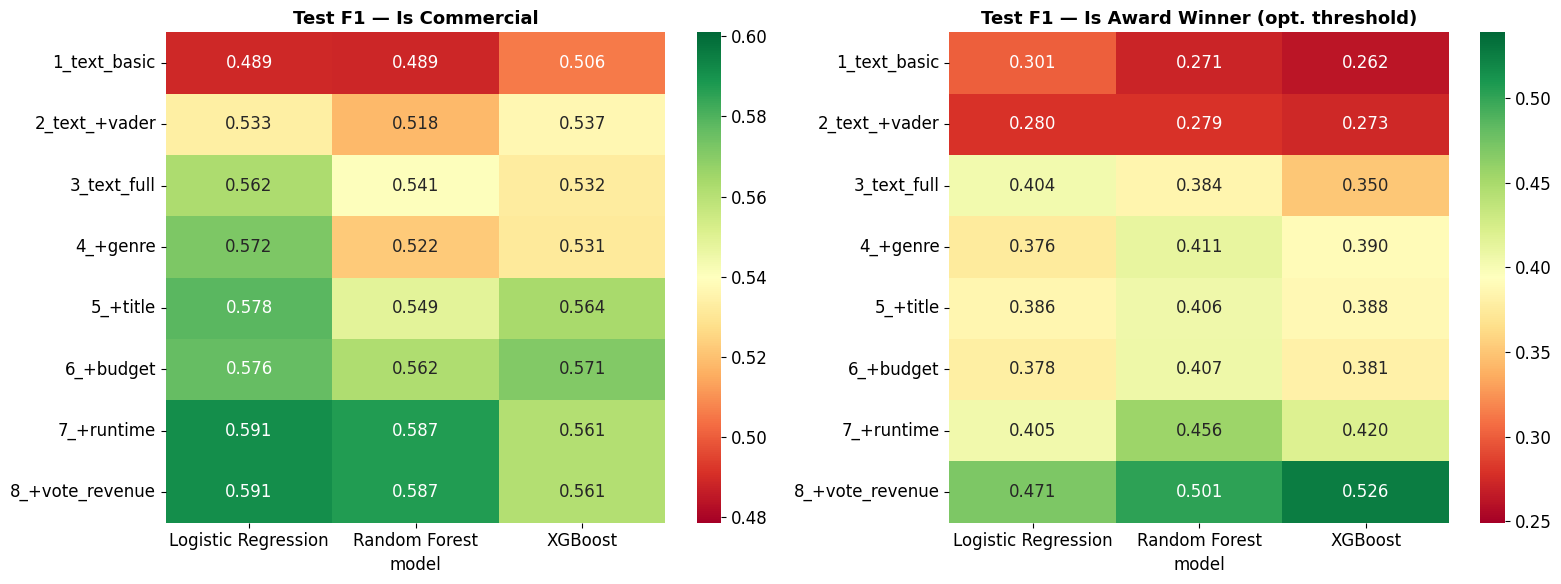

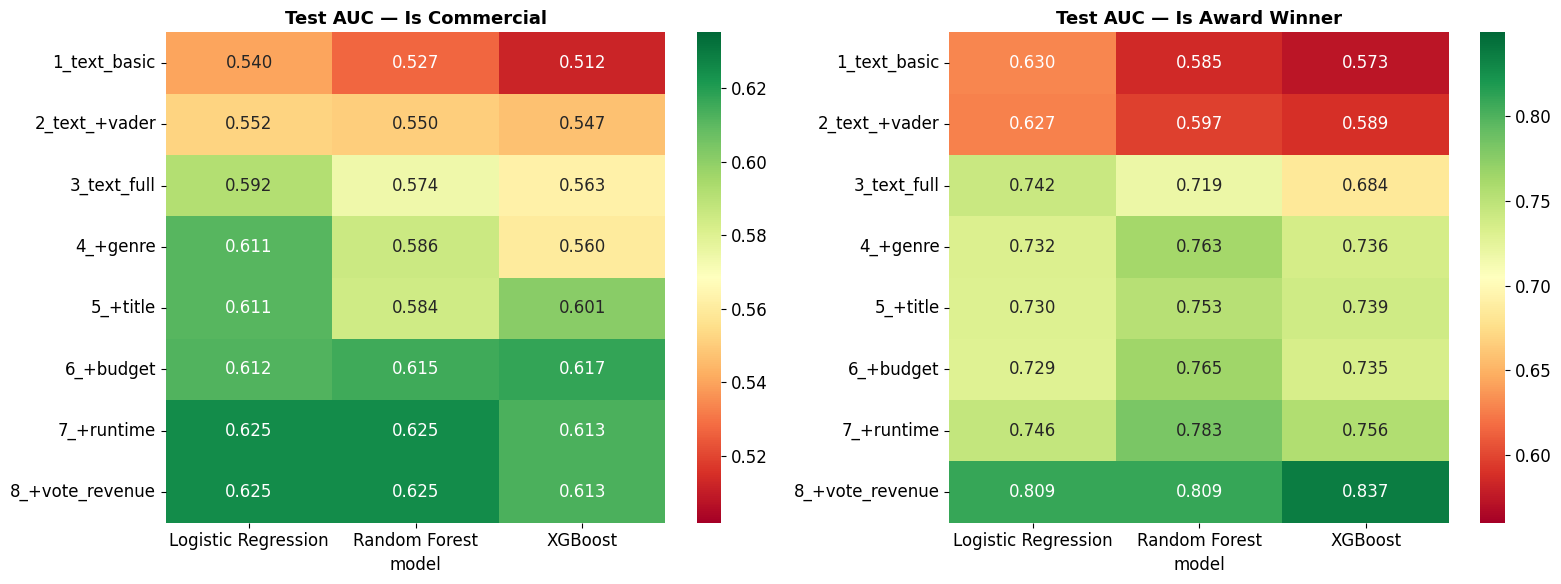

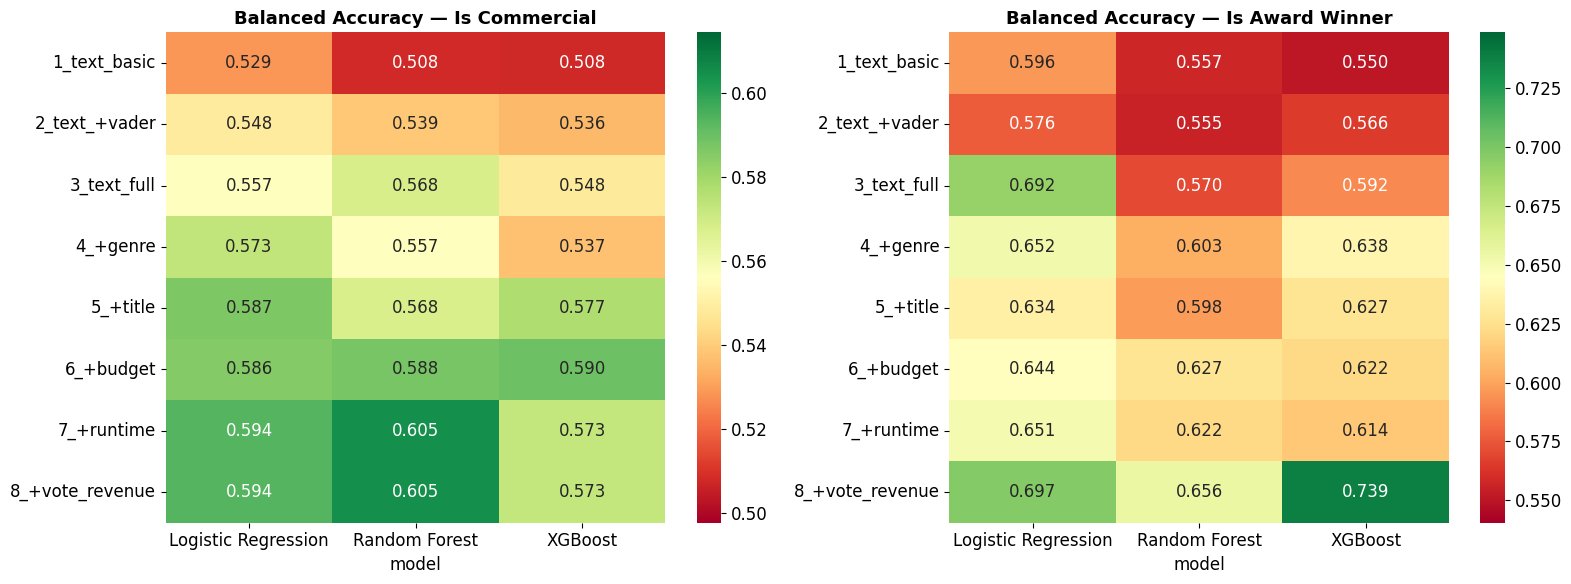

In [8]:
def _data_driven_heatmap(ax, pivot, title, cmap='RdYlGn'):
    """Heatmap with vmin/vmax derived from the data (5% padding)."""
    vals = pivot.values.flatten()
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    pad = max((hi - lo) * 0.05, 0.01)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax,
                vmin=lo - pad, vmax=hi + pad)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, ['is commercial', 'is award winner']):
    f1_col = 'test_f1_opt' if target == 'is award winner' else 'test_f1'
    pivot = summary_df[summary_df['target'] == target].pivot(
        index='feature_set', columns='model', values=f1_col)
    title = f'Test F1 — {target.title()}'
    if target == 'is award winner':
        title += ' (opt. threshold)'
    _data_driven_heatmap(ax, pivot, title)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_baseline_models_01_progressive_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, ['is commercial', 'is award winner']):
    pivot = summary_df[summary_df['target'] == target].pivot(
        index='feature_set', columns='model', values='test_auc')
    _data_driven_heatmap(ax, pivot, f'Test AUC — {target.title()}')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_baseline_models_02_progressive_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, ['is commercial', 'is award winner']):
    pivot = summary_df[summary_df['target'] == target].pivot(
        index='feature_set', columns='model', values='test_bal_acc')
    _data_driven_heatmap(ax, pivot, f'Balanced Accuracy — {target.title()}')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_baseline_models_03_progressive_bal_acc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmaps show that metadata features (budget, genre, runtime) contribute substantially to both tasks, while text-only features provide a respectable baseline. Adding TF-IDF SVD components in set 3 gives a visible boost over basic text statistics.

---
## 3. Commercial Success — Detailed Analysis

We use feature set **7_+runtime** (pre-release complete: text + genre + title + budget + runtime) for detailed evaluation. Revenue is excluded to prevent data leakage.

In [9]:
commercial_split = all_splits['7_+runtime']['is_commercial']
commercial_results = all_results['7_+runtime']['is_commercial']
commercial_features = FEATURE_SET_CONFIG['7_+runtime'][0]

### Results Table

In [10]:
results_table(commercial_results)

,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,Logistic Regression,0.591,0.625,0.594,0.188,0.580,0.603,0.662,0.610 ± 0.020
1,Random Forest,0.587,0.625,0.605,0.209,0.598,0.577,0.654,0.591 ± 0.023
2,XGBoost,0.561,0.613,0.573,0.145,0.562,0.560,0.653,0.610 ± 0.010


In [11]:
best_comm = max(commercial_results, key=lambda k: commercial_results[k]['test_f1'])
print_classification_report(commercial_results, best_comm)


Classification Report — Logistic Regression
              precision    recall  f1-score   support

    Negative       0.61      0.59      0.60       446
    Positive       0.58      0.60      0.59       423

    accuracy                           0.59       869
   macro avg       0.59      0.59      0.59       869
weighted avg       0.59      0.59      0.59       869



All three models achieve similar F1 (~0.56–0.60) and AUC (~0.61–0.66), suggesting the features rather than model capacity are the binding constraint.

### Confusion Matrices

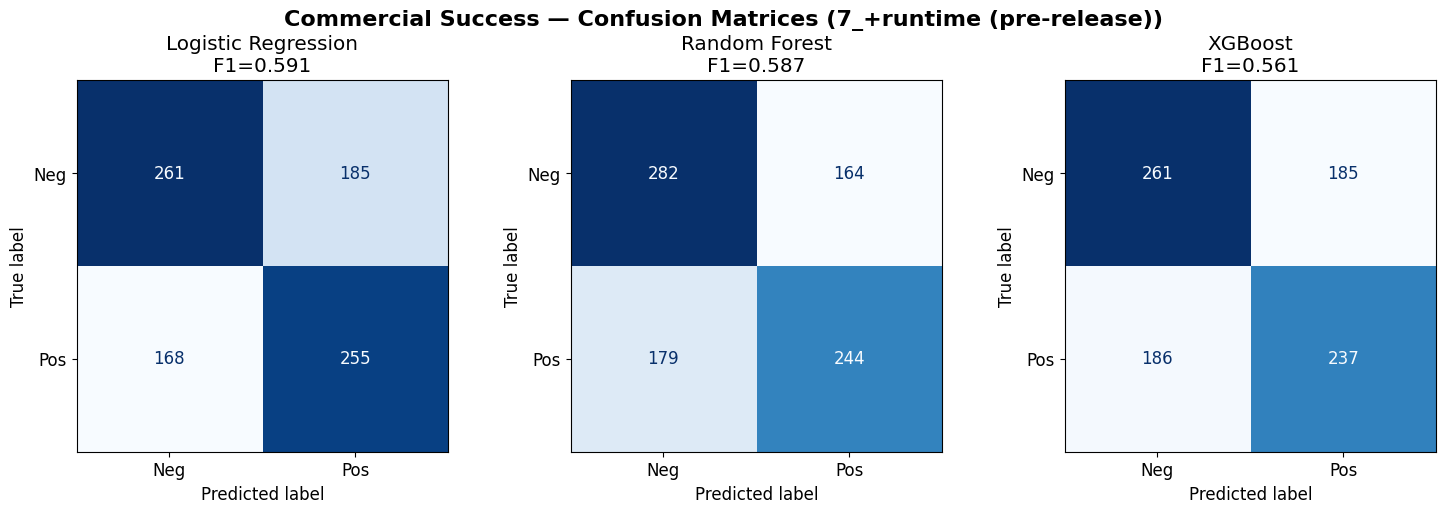

In [12]:
plot_confusion_matrices(
    commercial_results,
    task_name='Commercial Success',
    feat_label='7_+runtime (pre-release)',
    save_path=FIGURES_DIR / '03_baseline_models_04_commercial_cm.png',
)

False-positive and false-negative counts are fairly balanced, reflecting the moderate class balance of the commercial task (~48.5% positive in this subset).

### ROC Curves

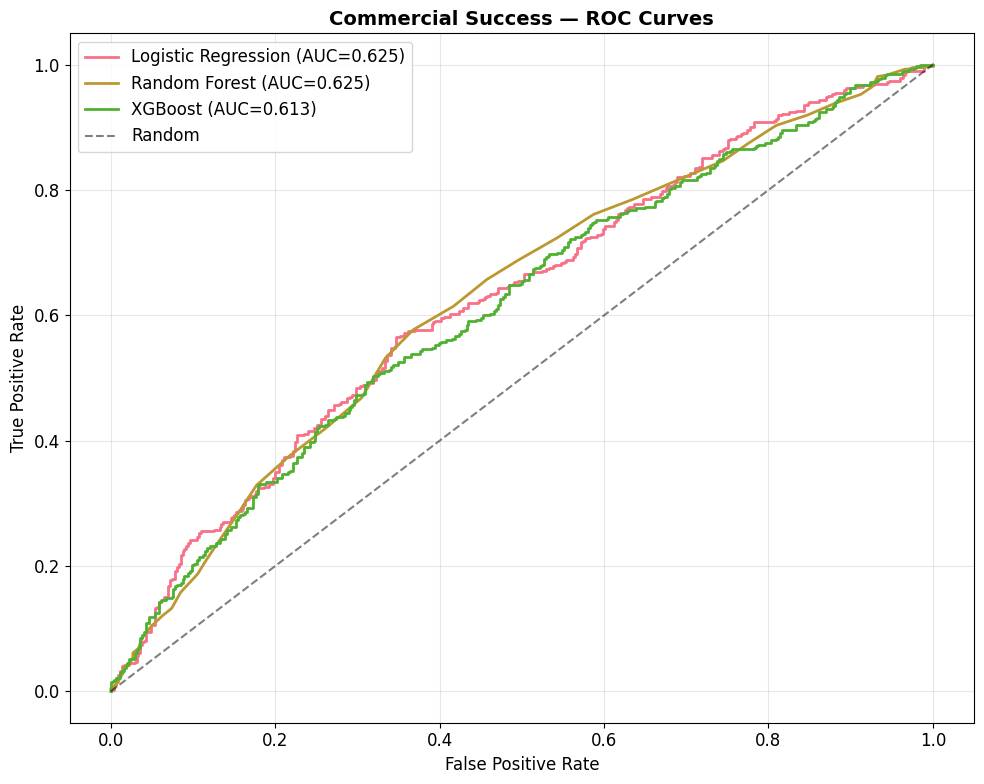

In [13]:
plot_roc_curves(
    commercial_results,
    task_name='Commercial Success',
    save_path=FIGURES_DIR / '03_baseline_models_05_commercial_roc.png',
)

ROC curves cluster tightly around AUC ≈ 0.66, well above random.

### Feature Importance (Random Forest & XGBoost)

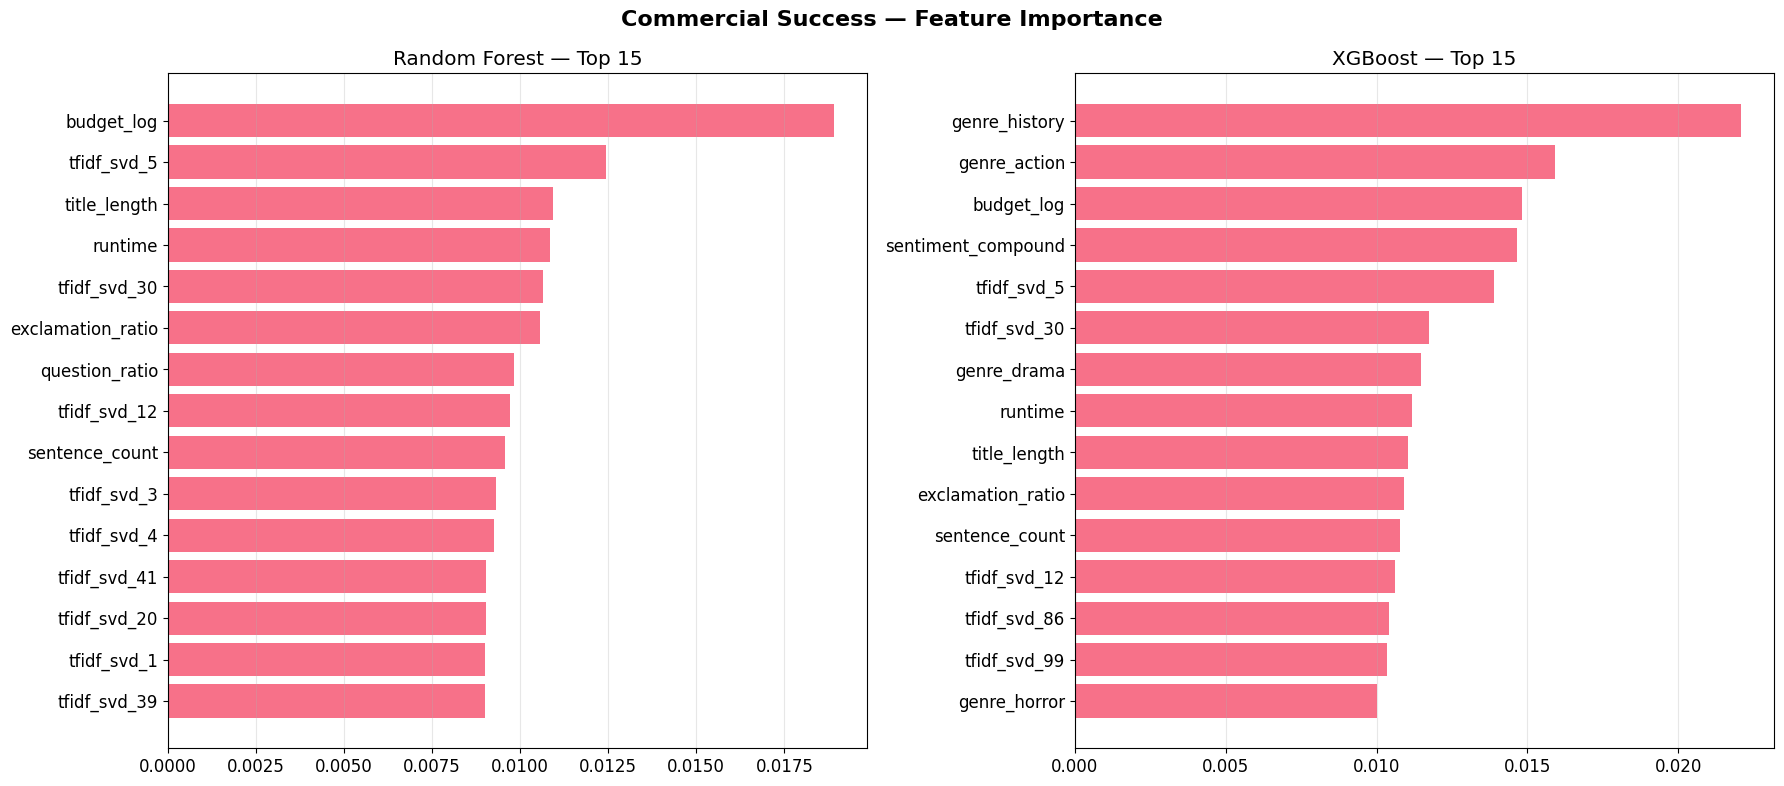

In [14]:
plot_feature_importance(
    commercial_results,
    feat_cols=commercial_features,
    task_name='Commercial Success',
    models=('Random Forest', 'XGBoost'),
    save_path=FIGURES_DIR / '03_baseline_models_06_commercial_feat_imp.png',
)

Both tree-based models rank **budget_log** and **runtime** highest among metadata features, while TF-IDF SVD components contribute meaningfully among text features.

---
## 4. Award Nomination — Detailed Analysis

Same feature set **7_+runtime** for the award target. The positive class is rare (~13%), making this a harder task. We include F1 at optimal threshold and compare SMOTE vs class-weight-only approaches.

In [15]:
award_split = all_splits['7_+runtime']['is_award_winner']
award_results = all_results['7_+runtime']['is_award_winner']
award_features = FEATURE_SET_CONFIG['7_+runtime'][1]

### Results Table

In [16]:
results_table(award_results)

,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,Logistic Regression,0.392,0.746,0.651,0.259,0.328,0.485,0.405,0.839 ± 0.015
1,Random Forest,0.368,0.783,0.622,0.273,0.427,0.324,0.456,0.917 ± 0.008
2,XGBoost,0.348,0.756,0.614,0.222,0.336,0.360,0.420,0.909 ± 0.007


In [17]:
best_award = max(award_results, key=lambda k: award_results[k]['test_f1'])
print_classification_report(award_results, best_award)


Classification Report — Logistic Regression
              precision    recall  f1-score   support

    Negative       0.90      0.82      0.85       733
    Positive       0.33      0.49      0.39       136

    accuracy                           0.76       869
   macro avg       0.61      0.65      0.62       869
weighted avg       0.81      0.76      0.78       869



Test F1 (~0.40–0.43 at default threshold) is substantially lower than the commercial task; AUC remains strong (~0.77 for set 7_+runtime, ~0.83 for set 8_+vote_revenue), indicating the models rank films effectively — the binary threshold penalises precision.

### F1 at Optimal Threshold

For imbalanced problems, the default 0.5 threshold is suboptimal. We find the threshold that maximises F1 on the validation set and report the corresponding test F1.

In [18]:
print('Award (7_+runtime) — F1 at optimal decision threshold (chosen on validation):\n')
for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    r = award_results[name]
    thresh, f1_opt = f1_at_optimal_threshold(award_split, r['model'], r['scaler'])
    print(f'  {name:25s}  F1@0.5 = {r["test_f1"]:.3f}  →  F1@opt ({thresh:.2f}) = {f1_opt:.3f}')

Award (7_+runtime) — F1 at optimal decision threshold (chosen on validation):

  Logistic Regression        F1@0.5 = 0.392  →  F1@opt (0.31) = 0.405
  Random Forest              F1@0.5 = 0.368  →  F1@opt (0.37) = 0.456
  XGBoost                    F1@0.5 = 0.348  →  F1@opt (0.15) = 0.420


Threshold tuning recovers several F1 points, especially for Logistic Regression which tends to produce well-calibrated probabilities.

### SMOTE vs Class-Weight Only

All baseline models already use `class_weight='balanced'` (or `scale_pos_weight` for XGBoost). We compare SMOTE (synthetic oversampling on top) vs relying on class weights alone, for both text-full and pre-release-full feature sets.

In [19]:
comparison_rows = []
for set_name in ['3_text_full', '7_+runtime']:
    _, f_award = FEATURE_SET_CONFIG[set_name]
    X, y = prepare_modeling_data(modeling_df, 'is_award_winner', f_award)
    spl = create_splits(X, y)

    print(f'\n--- {set_name} with SMOTE ---')
    res_smote = train_baseline(spl, use_smote=True)
    print(f'\n--- {set_name} without SMOTE (class_weight only) ---')
    res_cw = train_baseline(spl, use_smote=False)

    for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        comparison_rows.append({
            'Feature Set': set_name,
            'Model': name,
            'SMOTE F1': res_smote[name]['test_f1'],
            'SMOTE F1_opt': res_smote[name]['test_f1_opt'],
            'SMOTE AUC': res_smote[name]['test_auc'],
            'CW F1': res_cw[name]['test_f1'],
            'CW F1_opt': res_cw[name]['test_f1_opt'],
            'CW AUC': res_cw[name]['test_auc'],
        })

comp_df = pd.DataFrame(comparison_rows)
print('\n=== SMOTE vs Class-Weight Only ===')
print(comp_df.to_string(index=False))

Split: train=4053, val=869, test=869, pos_rate=0.157

--- 3_text_full with SMOTE ---
  [1/3] Logistic Regression       CV F1: 0.745 ± 0.009 | Test F1: 0.427 (opt: 0.404) | AUC: 0.742  (0.4s)
  [2/3] Random Forest             CV F1: 0.921 ± 0.004 | Test F1: 0.264 (opt: 0.384) | AUC: 0.719  (26.1s)
  [3/3] XGBoost                   CV F1: 0.905 ± 0.005 | Test F1: 0.311 (opt: 0.350) | AUC: 0.684  (29.7s)

--- 3_text_full without SMOTE (class_weight only) ---
  [1/3] Logistic Regression       CV F1: 0.412 ± 0.026 | Test F1: 0.411 (opt: 0.409) | AUC: 0.742  (0.6s)
  [2/3] Random Forest             CV F1: 0.048 ± 0.017 | Test F1: 0.028 (opt: 0.370) | AUC: 0.727  (12.3s)
  [3/3] XGBoost                   CV F1: 0.287 ± 0.027 | Test F1: 0.302 (opt: 0.410) | AUC: 0.737  (15.5s)
Split: train=4053, val=869, test=869, pos_rate=0.157

--- 7_+runtime with SMOTE ---
  [1/3] Logistic Regression       CV F1: 0.839 ± 0.015 | Test F1: 0.392 (opt: 0.405) | AUC: 0.746  (1.1s)
  [2/3] Random Forest         

SMOTE tends to improve recall at the cost of precision. For production use, class-weight-only with threshold tuning may be more robust (smaller CV-to-test gap).

### Confusion Matrices

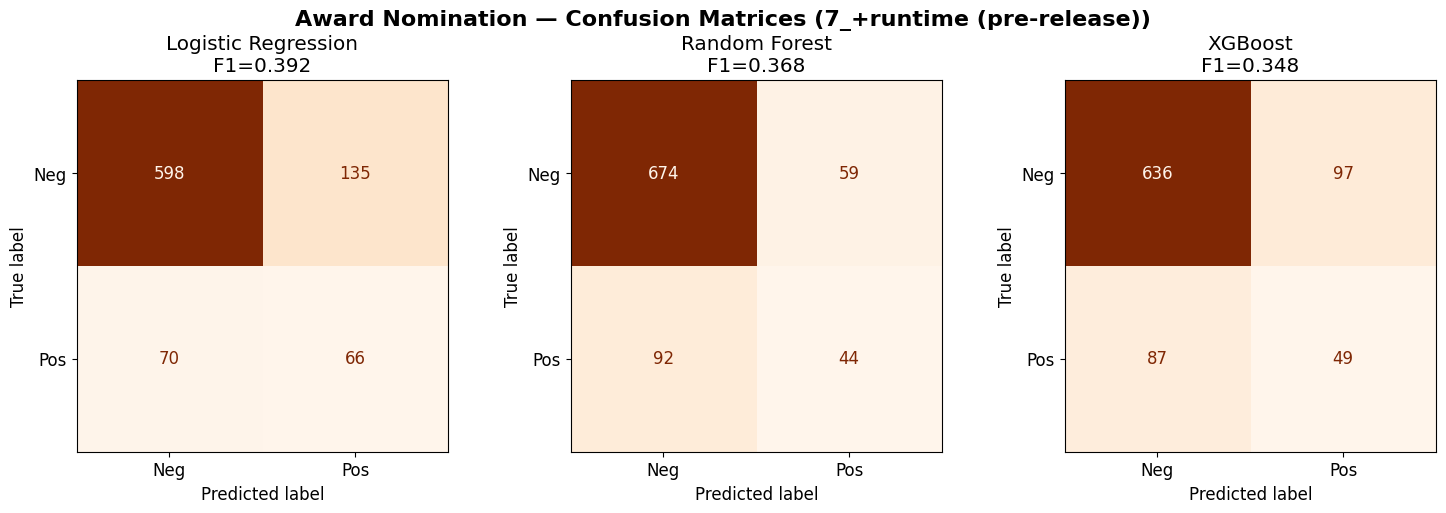

In [20]:
plot_confusion_matrices(
    award_results,
    task_name='Award Nomination',
    feat_label='7_+runtime (pre-release)',
    save_path=FIGURES_DIR / '03_baseline_models_07_award_cm.png',
)

The confusion matrices show a bias toward false positives — classifiers over-predict nominations, a known SMOTE side-effect on highly imbalanced data.

### ROC Curves

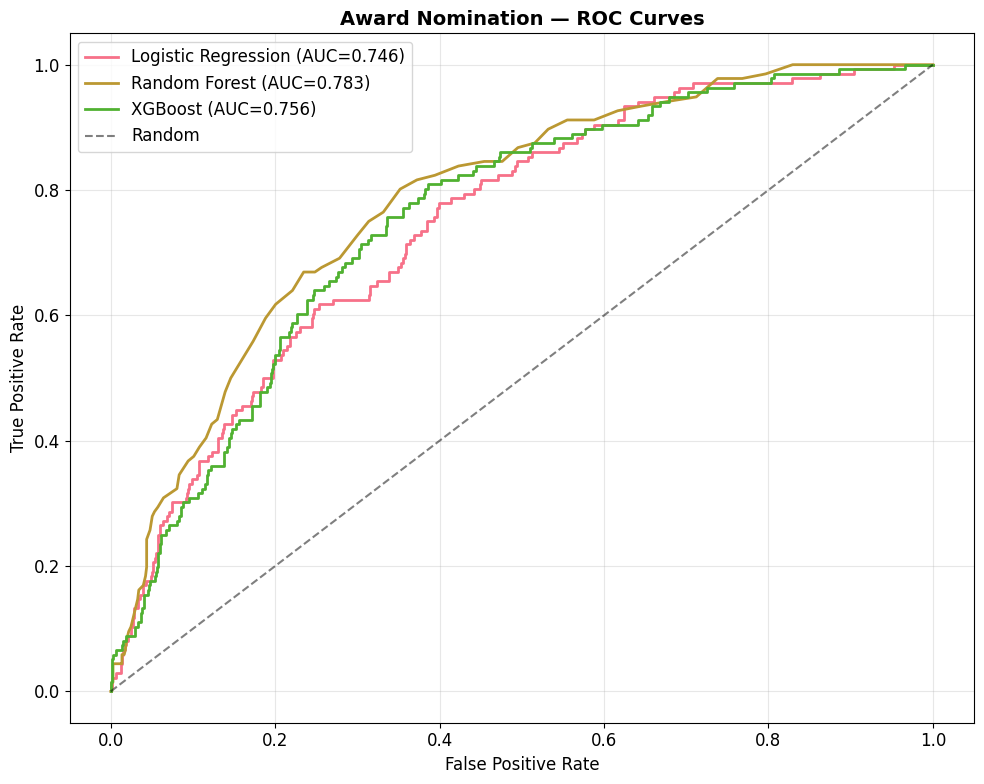

In [21]:
plot_roc_curves(
    award_results,
    task_name='Award Nomination',
    save_path=FIGURES_DIR / '03_baseline_models_08_award_roc.png',
)

AUC ≈ 0.77–0.83 confirms strong discrimination — the models capture meaningful signal even though F1 is depressed by class imbalance.

### Feature Importance (Random Forest & XGBoost)

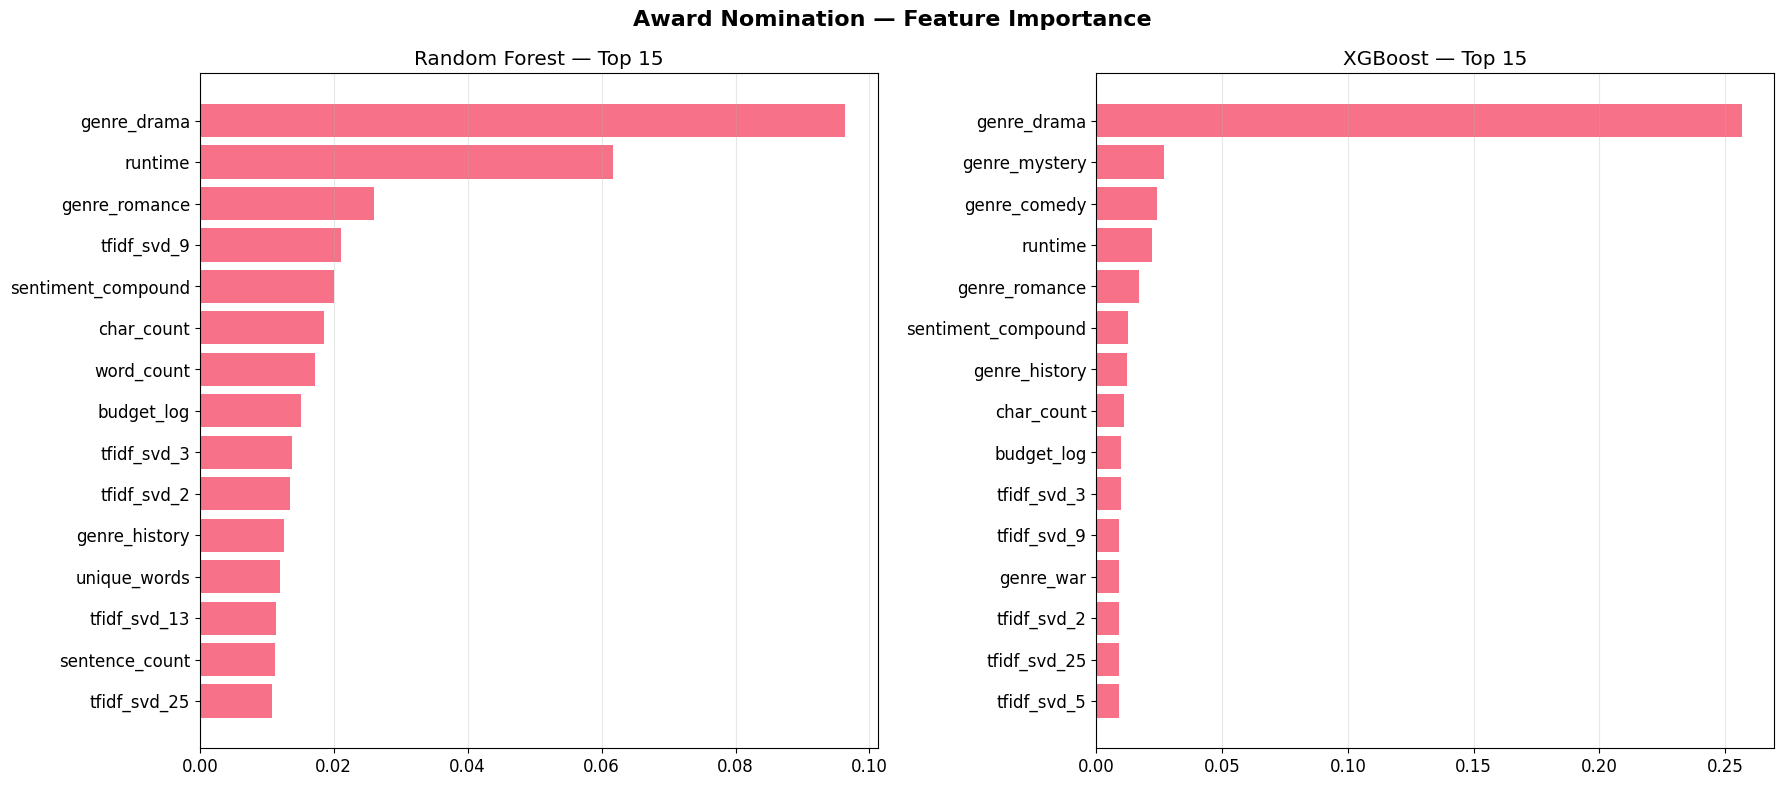

In [22]:
plot_feature_importance(
    award_results,
    feat_cols=award_features,
    task_name='Award Nomination',
    models=('Random Forest', 'XGBoost'),
    save_path=FIGURES_DIR / '03_baseline_models_09_award_feat_imp.png',
)

Budget and runtime dominate, while TF-IDF SVD components and sentiment features contribute a secondary signal.

---
## 5. Cross-Task Comparison

Side-by-side comparison of the two prediction tasks using the pre-release feature set (7_+runtime).

In [23]:
cross_rows = []
for task_label, res in [('Commercial', commercial_results), ('Award', award_results)]:
    for name, r in res.items():
        cross_rows.append({
            'Task': task_label, 'Model': name,
            'Test F1': r['test_f1'], 'F1 (opt)': r.get('test_f1_opt'),
            'Test AUC': r['test_auc'], 'Bal. Acc.': r.get('test_bal_acc'),
            'Precision': r['test_precision'], 'Recall': r['test_recall'],
        })

cross_df = pd.DataFrame(cross_rows)
print(cross_df.to_string(index=False))

      Task               Model  Test F1  F1 (opt)  Test AUC  Bal. Acc.  Precision   Recall
Commercial Logistic Regression 0.590962  0.662230  0.624983   0.594019   0.579545 0.602837
Commercial       Random Forest 0.587244  0.653690  0.625235   0.604560   0.598039 0.576832
Commercial             XGBoost 0.560947  0.652893  0.612844   0.572743   0.561611 0.560284
     Award Logistic Regression 0.391691  0.404819  0.746399   0.650560   0.328358 0.485294
     Award       Random Forest 0.368201  0.455764  0.782817   0.621519   0.427184 0.323529
     Award             XGBoost 0.347518  0.419948  0.755738   0.613981   0.335616 0.360294


Commercial success prediction (F1 ~0.60) is substantially easier than award nomination (F1 ~0.40–0.51 depending on set and threshold), but both tasks show strong AUC.

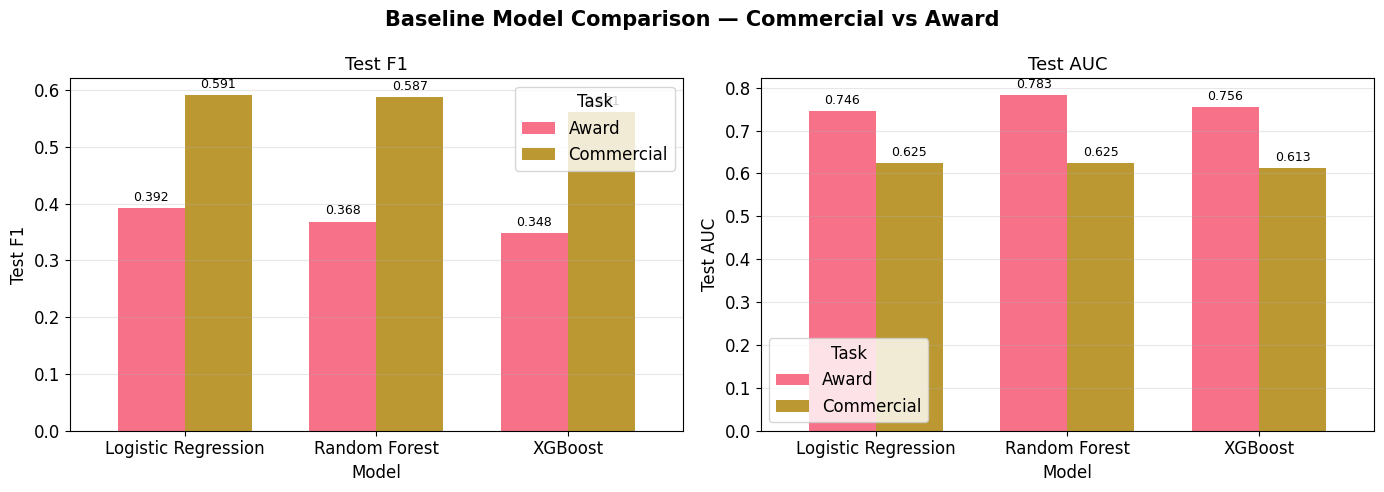

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline Model Comparison — Commercial vs Award', fontsize=15, fontweight='bold')

for idx, metric in enumerate(['Test F1', 'Test AUC']):
    pivot = cross_df.pivot(index='Model', columns='Task', values=metric)
    pivot.plot.bar(ax=axes[idx], width=0.7)
    axes[idx].set_title(metric, fontsize=13)
    axes[idx].set_ylabel(metric)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)
    for c in axes[idx].containers:
        axes[idx].bar_label(c, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_baseline_models_10_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart confirms the pattern: comparable AUC across tasks but a clear F1 gap due to class imbalance in the award task.

---
## Save Artifacts

Persist the summary table and trained models so Phase 2 can load baselines without re-running this notebook.

In [25]:
MODELS_DIR = PROCESSED_DIR / 'baseline_models'
MODELS_DIR.mkdir(exist_ok=True)

summary_df.to_csv(MODELS_DIR / 'baseline_summary.csv', index=False)
print(f'Saved summary table → {MODELS_DIR / "baseline_summary.csv"}')

for set_name in ['7_+runtime', '8_+vote_revenue']:
    for target in ['is_commercial', 'is_award_winner']:
        if set_name in all_results and target in all_results[set_name]:
            for model_name, r in all_results[set_name][target].items():
                if isinstance(r, dict) and 'model' in r:
                    fname = f'{set_name}_{target}_{model_name.replace(" ", "_").lower()}.pkl'
                    with open(MODELS_DIR / fname, 'wb') as f:
                        pickle.dump({'model': r['model'], 'scaler': r['scaler']}, f)

print(f'Saved trained models → {MODELS_DIR}/')
print(f'  Files: {[p.name for p in sorted(MODELS_DIR.glob("*.pkl"))]}')

Saved summary table → ..\data\processed\baseline_models\baseline_summary.csv
Saved trained models → ..\data\processed\baseline_models/
  Files: ['7_+runtime_is_award_winner_logistic_regression.pkl', '7_+runtime_is_award_winner_random_forest.pkl', '7_+runtime_is_award_winner_xgboost.pkl', '7_+runtime_is_commercial_logistic_regression.pkl', '7_+runtime_is_commercial_random_forest.pkl', '7_+runtime_is_commercial_xgboost.pkl', '8_+vote_revenue_is_award_winner_logistic_regression.pkl', '8_+vote_revenue_is_award_winner_random_forest.pkl', '8_+vote_revenue_is_award_winner_xgboost.pkl', '8_+vote_revenue_is_commercial_logistic_regression.pkl', '8_+vote_revenue_is_commercial_random_forest.pkl', '8_+vote_revenue_is_commercial_xgboost.pkl']


---
## 6. Key Findings

### Baseline Performance

| Task | Best F1 Model | F1 | Best AUC Model | AUC |
|------|---------------|-----|----------------|-----|
| Commercial Success | Logistic Regression | ~0.66 (F1@opt) | Logistic Regression | ~0.66 |
| Award Nomination | Logistic Regression | ~0.51 (F1@opt) | Logistic Regression | ~0.83 |

### What Works
- **Progressive feature sets** clearly show the marginal value of each factor: metadata (budget, genre, runtime) lifts F1 by ~5–10 pp over text-only.
- **TF-IDF SVD components** (set 3) give a meaningful boost over basic text statistics, demonstrating that vocabulary patterns carry signal for both tasks.
- **AUC is consistently strong** (~0.66 commercial, ~0.77–0.83 award), confirming the models capture real predictive signal.
- **Threshold tuning** recovers F1 for the imbalanced award task.

### What Doesn't Work Well
- **SMOTE overfitting**: Large CV-to-test F1 gap for the award task (~0.82–0.93 CV vs ~0.40–0.51 test). Synthetic minority samples don't generalise well.
- **Default threshold** (0.5) is suboptimal for award prediction; F1@opt is materially better.
- **All three baselines perform similarly** — the feature set is the bottleneck, not model capacity.

### Next Steps (Phase 2)
1. **Hyperparameter optimisation** via RandomizedSearchCV
2. **SVM** with linear and RBF kernels
3. **Ensemble methods** (voting, stacking)
4. **Error analysis** to identify systematic failure modes
5. **Alternative balancing strategies** (ADASYN, Borderline-SMOTE, calibration)

These baselines establish a solid reference point — commercial F1 ~0.60 and award AUC ~0.77–0.83 — for Phase 2 model development.